# SudoCode: Vietnamese Customer Review Classification

## 1. Problem Introduction
Trong bài toán này, chúng ta xây dựng một mô hình **Machine Learning để phân loại đánh giá (review) của khách hàng bằng tiếng Việt**.

Dataset bao gồm các đánh giá của khách hàng về sản phẩm. Mỗi review được gán một **label** đại diện cho mức độ cảm xúc của khách hàng.

### Input

Đầu vào của mô hình là một đoạn review bằng tiếng Việt.

Ví dụ:

> "máy dùng hay bị đơ máy"

> "Tuyệt vời. Hàng FPT cửa hàng"

### Output

Mô hình sẽ dự đoán review thuộc một trong ba lớp:

| Label | Sentiment | Ý nghĩa |
|------:|-----------|---------|
| `0` | Negative | Đánh giá tiêu cực |
| `1` | Neutral | Đánh giá trung lập |
| `2` | Positive | Đánh giá tích cực |

Ví dụ:

| Review | Label |
|---|---:|
| máy dùng hay bị đơ máy | 0 |
| phủ sóng thấp quá đi khoảng 3 4m là mất sóng | 0 |
| Chưa đo đúng bước chân rõ, nhiều khi gián đoạn | 1 |
| Kết nối tốt, mối nối không khít gây đau tai | 1 |
| Tuyệt vời. Hàng FPT cửa hàng | 2 |

---

## 2. Problem Type

Đây là bài toán **Supervised Learning** thuộc nhóm **Multiclass Text Classification**.

Ta có:

- **Feature (`X`)**: nội dung review của khách hàng.
- **Target (`y`)**: sentiment label (`0`, `1`, `2`).
- **Number of classes**: 3.

---

## 3. Machine Learning Pipeline

Quy trình xây dựng mô hình:
1. **Raw Vietnamese Reviews**

2. **Text Cleaning**  
- Chuyển về chữ thường
- Loại bỏ URL / HTML
- Loại bỏ số nếu không cần thiết
- Loại bỏ ký tự đặc biệt

3. **Vietnamese Word Segmentation / Tokenization**

4. **Stopword Removal**
 
5. **Feature Extraction**
- TF-IDF
 
6. **Train/Test Split**

7. **Classification Model**
- Logistic Regression
- Naive Bayes
- SVM
 
8. **Evaluation**
    - Accuracy
    - Precision
    - Recall
    - F1-score

---

## 4. Objective

Mục tiêu của bài toán là xây dựng và đánh giá mô hình có khả năng tự động xác định **sentiment của một review tiếng Việt**, từ đó có thể ứng dụng vào:

- Phân tích phản hồi của khách hàng.
- Theo dõi mức độ hài lòng về sản phẩm.
- Phát hiện các đánh giá tiêu cực.
- Tổng hợp sentiment của lượng lớn review.
- Hỗ trợ doanh nghiệp phân tích chất lượng sản phẩm và dịch vụ.

## 0. Setup & Profiling Data

In [1]:
pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from underthesea import word_tokenize

In [3]:
df = pd.read_csv("/kaggle/input/datasets/tuannguyenvananh/vietnamese-text-classification-dataset/train.csv", header=None, names=['label', 'review'])
df.head(10)

,label,review
0,0,máy dùng hay bị đơ máy
1,0,chỉ có dây cáp nguồn không có adapter sao sử d...
2,0,Chất lượng quá kém Mới dùng được 2 ngày loa ba...
3,0,Usb tôi vừa mới nhận usb này Rất bực bội vì cá...
4,2,Tuyệt vời. Hàng FPT cửa hàng
5,1,Chưa đo đúng bước chân rõ Nhiều khi gián đoạn ...
6,0,phủ sóng thấp quá đi khoảng 3 4m là mất sóng
7,1,Kết nối tốt Mối nối không khít gây đau tai 1 K...
8,0,2 Loa nhỏ nghe bị rè Âm thanh chưa tốt hơi thấ...
9,0,Đặt i12 shop giao i11 thất vọng


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   3040 non-null   int64 
 1   review  3040 non-null   object
dtypes: int64(1), object(1)
memory usage: 47.6+ KB


- Không có row nào bị null

In [5]:
df['label'].unique()

array([0, 2, 1])

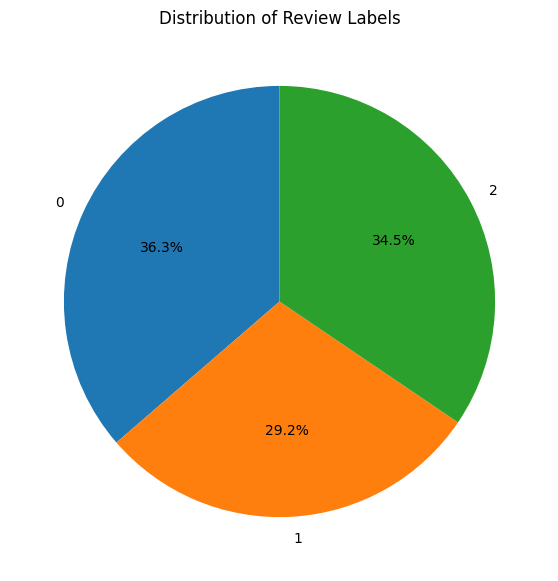

In [6]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(7,7))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Review Labels')
plt.show()

- Đa số label là 0 (nhiều đánh giá tiêu cực)

In [7]:
df["review_length"] = df["review"].fillna("").apply(
    lambda x: len(str(x).split())
)

df[["review", "label", "review_length"]].head()

,review,label,review_length
0,máy dùng hay bị đơ máy,0,6
1,chỉ có dây cáp nguồn không có adapter sao sử d...,0,29
2,Chất lượng quá kém Mới dùng được 2 ngày loa ba...,0,26
3,Usb tôi vừa mới nhận usb này Rất bực bội vì cá...,0,37
4,Tuyệt vời. Hàng FPT cửa hàng,2,6


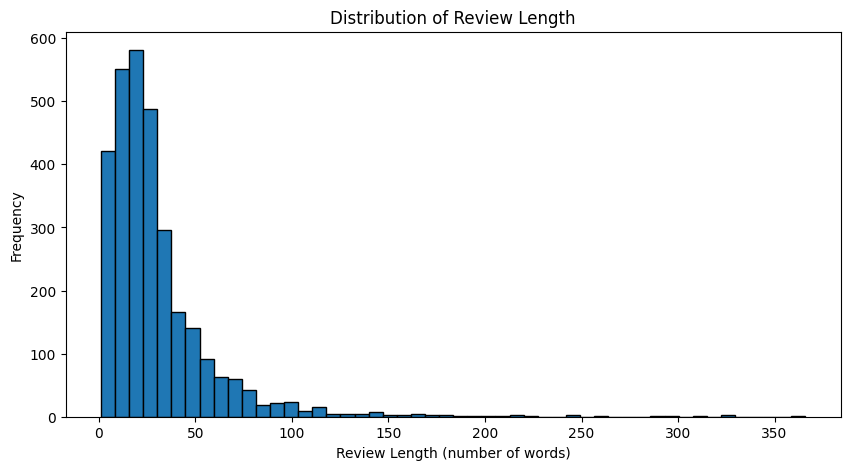

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["review_length"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Review Length (number of words)")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")

plt.show()

In [9]:
df["review_length"].describe()

count    3040.000000
mean       29.826316
std        29.886306
min         1.000000
25%        13.000000
50%        22.000000
75%        36.000000
max       366.000000
Name: review_length, dtype: float64

In [10]:
df["review_length"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.50     22.00
0.75     36.00
0.90     60.00
0.95     79.00
0.99    149.22
Name: review_length, dtype: float64

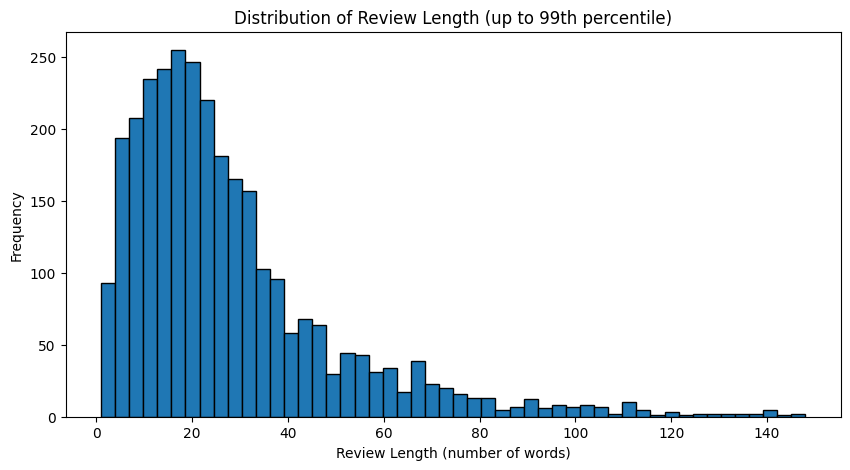

In [11]:
limit = df["review_length"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df["review_length"] <= limit, "review_length"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Review Length (number of words)")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length (up to 99th percentile)")

plt.show()

- Đa số review có độ dài từ khoảng 0 đến 150
- Còn giá trị lơn hơn có thể là giá trị ngoại lệ, hoặc do lỗi gõ của người dùng

In [12]:
pd.set_option('display.max_colwidth', None)

In [13]:
df.loc[
    df['review_length'] > 150,
    ['review', 'label', 'review_length']
]

,review,label,review_length
163,Thiết bị nhỏ gọn pin tốt giá cả phù hợp Mình có mua 1 cái hồi đầu tháng 7 2019 để gắn lên xe hơi cho khách sử dụng Về Tiki thì giao hàng vẫn rất nhanh nhà mình ở huyện tận Đức Hòa sau 1 ngày là có hàng luôn Màu đen nhỏ gọn cỡ cái ví nam thôi Dễ sử dụng gắn sim vào là sài thôi có cái màn hình nhỏ nhỏ ở trước hiển thị tốc độ down up tuy nhiên màn hình hơi kém bạn mang ra nắng một tí thì hơi khó nhìn số dung lượng sử dụng Thiết bị bắt sóng khá tốt dù ở xã huyện xa thưa người Pin thì sài liên tục được tầm 5 tiếng thôi nhưng mình đi xe hơi nên cắm luôn vào cái cổng USB vừa xạc vừa sài luôn sài hơn nửa tháng rồi vẫn thấy ổn trong tầm giá vậy thì mình thấy TP Link này ổn rồi sóng 4G xem Youtube thoải mái luôn Bữa mình thử kết nối tới 8 điện thoại rồi mà vẫn sử dụng bình thường với lại có phần mềm trên IOS và Android để quản lý cũng tiện Tóm lại tầm giá này thì các bạn có thể mua được,2,213
267,Đánh giá sản phẩm hàng Tiki đúng chính hãng của Samsung thời gian bảo hành dài hơn các đại lý khác nên bỏ thêm khoảng vài chục để được 10 năm bảo hành thì mình thấy rất đáng giao hàng nhanh chưa có gì đề phàn nàn tikiNgoài việc muốn liên hệ chat tư vấn với tiki thi thiệt rườm ra mình kiếm không ra bên góc phải màn hình tiki nên để tư vấn như một số đại lý khác vì mua hàng online cần được tư vấn nhiều như mình thích chat không thích nói chuyện qua điện thoại thì sao mà thông tin bên tiki toàn trả lời sẵn để người ta nghiên cứu mà nhiều lúc không rõ tiki để rõ nơi tư vấn chat nhiệt tình những gì ma khách hàng chưa hiểu thì thay vì thời gian tìm hiểu rắc rối về tiki thì người ta dùng thời gian đó để tìm mặt hàng ưng ý thì tốt hơn,1,165
308,Đã xài qua rất nhiều portable wifi 3g 4g và có cảm nhận về TP Link 7350 Mình đã từng xài qua nhiều con portable wifi 3g 4g từ Hame A1 Hame R1 ZMI Sierra Wireless 754s cả đàn em TP link 5350 thì thấy con này là được nhất về sóng 3G sóng wifi và cả thời lượng pin 2500mA pin thì chỉ thua mỗi mình ZMI vì con này có sạc dự phòng 5000mA nhưng bắt sóng thì không có con nào bằng TP Link 7350 có apps quản lý trên mobile có 2 băng tầng dual band 24Ghz 5Ghz khuyên các bạn nên xài băng tầng 5Ghz nếu điện thoại hỗ trợ vì tốc độ nhanh hơn nhưng có bù lại sóng sẽ ngắn hơn 24GHz có 4G LTE Cat 4 150 50Mbps hỗ trợ nhiều band cho mạng 4G như FDD LTE 137820 Việt Nam mình hiện đang xài band 7 2600Mhz Mobifone và Viettel,2,159
386,Tốt hàng chính hãng Con B100 này mình dùng 3 4 con gì rồi mỗi con dùng trung bình hơn 1 năm là hỏng Với tần suất dùng của mình thì trụ được 1 năm quá là bền rồi Các bạn có thể hiểu là nếu mình mua chuột khác thì chỉ dùng cỡ chưa đến 1 tháng là hỏng Mình dùng 1 ngày khoảng 12 đến 16 tiếng gần như liên tục Và khó có em nào trụ được với mình Mình dùng không những nhiều mà tần suất click cũng cực cao và nhanh Nói chung về độ bền thì em này gần như vô đối trong tầm dưới 1 củ Còn về thiết kế thì đơn giản cầm nắm tốt Về cảm giác click và lăn con lăn cũng tốt Nói chung đáng 5 chả có em nào rẻ mà được như vậy đâu Mua đi các thím,2,151
497,Âm thanh tạm được mic và điều khiển tốt Trước khi quyết định mua mình cũng đã tìm hiểu ở nhiều trang web phần lớn là các trang bằng tiếng anh Ở đó cũng có khá nhiều người khen cũng như ở tiki Vì vậy mình đã đặt tai nghe này Âm thanh: Nhiều người khen âm thanh của tai nghe nay nhưng mình thì thấy âm thanh không được tốt lăm khi so sanh với tai nghe đắt tiền hơn một chút High range thì tạm được Bass thì tốt hơn High một chút còn phần Mid range bị ảnh hưởng bởi Bass cho nên âm thanh không được hoàn hào lắm Nhưng với mức giá này thì chấp nhận được Mic: Micro thì mình thấy tốt Mình ghi âm thử và thấy nghe khá là rõ Điều khiền: Bấm nút 1 lần là Play Pause; Bấm 2 lần liên tiếp là chuyển sang bài hát tiếp theo; Bấm 3 lần liên tiếp là quay lại bài hát trước đó hoặc bật bài hát hiện tại lại từ đầu,1,180
592,Không hài lòng Mình mới mua sản phẩm này và 

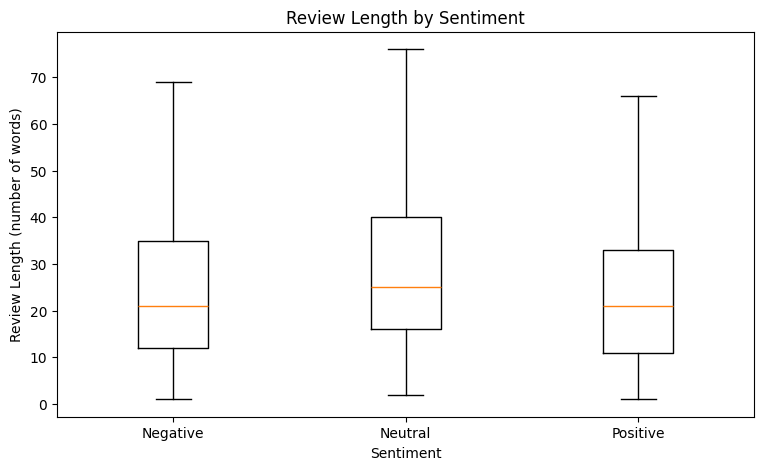

In [14]:
label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

plot_df = df.copy()
plot_df["sentiment"] = plot_df["label"].map(label_names)

data = [
    plot_df.loc[plot_df["label"] == 0, "review_length"],
    plot_df.loc[plot_df["label"] == 1, "review_length"],
    plot_df.loc[plot_df["label"] == 2, "review_length"]
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data,
    tick_labels=["Negative", "Neutral", "Positive"],
    showfliers=False
)

plt.xlabel("Sentiment")
plt.ylabel("Review Length (number of words)")
plt.title("Review Length by Sentiment")

plt.show()

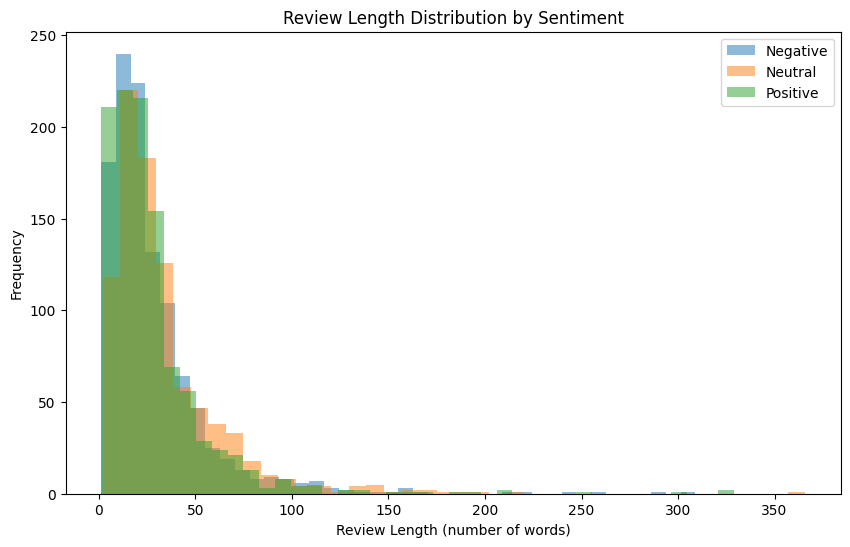

In [15]:
plt.figure(figsize=(10, 6))

for label in sorted(df["label"].unique()):
    subset = df[df["label"] == label]

    plt.hist(
        subset["review_length"],
        bins=40,
        alpha=0.5,
        label=label_names[label]
    )

plt.xlabel("Review Length (number of words)")
plt.ylabel("Frequency")
plt.title("Review Length Distribution by Sentiment")
plt.legend()

plt.show()

## 1. Preprocessing text

In [16]:
import re
import pandas as pd

from underthesea import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================================================
# 1. Vietnamese stopwords
# =========================================================

# vietnamese_stopwords = {
#     "bị", "bởi", "cả", "các", "cái", "cần", "càng", "chỉ",
#     "chiếc", "cho", "chứ", "chưa", "chuyện", "có", "có_thể",
#     "cứ", "của", "cùng", "cũng", "đã", "đang", "đây", "để",
#     "đến", "được", "do", "đó", "gì", "khi", "không", "là",
#     "lại", "lên", "lúc", "mà", "mỗi", "một", "này", "nên",
#     "nếu", "ngay", "nhiều", "như", "nhưng", "những", "nơi",
#     "nữa", "phải", "qua", "ra", "rằng", "rất", "rồi", "sau",
#     "sẽ", "theo", "thì", "trên", "trước", "từ", "từng", "và",
#     "vẫn", "vào", "về", "vì", "việc", "với", "vừa"
# }
# =========================================================
# 2. Text preprocessing
# =========================================================

def preprocess_text(text):
    # Handle missing values
    if pd.isna(text):
        return ""
    text = str(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Keep Vietnamese letters and spaces
    text = re.sub(r'[^a-zA-ZÀ-ỹ\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Vietnamese word segmentation
    # Example: "sản phẩm rất tốt"
    #       -> "sản_phẩm rất tốt"
    # text = word_tokenize(text, format="text")
    # Remove stopwords
    tokens = text.split()
    # tokens = [token for token in tokens if token not in vietnamese_stopwords]
    return " ".join(tokens)

In [17]:
# Apply preprocess dataset
df["review_clean"] = df["review"].apply(preprocess_text)
df[["review", "review_clean"]].head()

,review,review_clean
0,máy dùng hay bị đơ máy,máy dùng hay bị đơ máy
1,chỉ có dây cáp nguồn không có adapter sao sử dụng chỉ có dây cáp nguồn không có adapter sao sử dụng hàng tiki training gì kì cục vậy,chỉ có dây cáp nguồn không có adapter sao sử dụng chỉ có dây cáp nguồn không có adapter sao sử dụng hàng tiki training gì kì cục vậy
2,Chất lượng quá kém Mới dùng được 2 ngày loa bass có âm thanh rè rè dù không mở gì Không tin tưởng được chất lượng,chất lượng quá kém mới dùng được ngày loa bass có âm thanh rè rè dù không mở gì không tin tưởng được chất lượng
3,Usb tôi vừa mới nhận usb này Rất bực bội vì cái nắp usb này rất cứng không thể mở ra được Và cái hộp đựng usb này dường như bị ai đó cắt ra trước đó,usb tôi vừa mới nhận usb này rất bực bội vì cái nắp usb này rất cứng không thể mở ra được và cái hộp đựng usb này dường như bị ai đó cắt ra trước đó
4,Tuyệt vời. Hàng FPT cửa hàng,tuyệt vời hàng fpt cửa hàng


In [18]:
from collections import Counter

all_words = " ".join(df["review_clean"].dropna()).split()

word_counts = Counter(all_words)

top_10_words = word_counts.most_common(10)

top_10_words

[('không', 2610),
 ('hàng', 1918),
 ('được', 1571),
 ('có', 1154),
 ('tốt', 1081),
 ('thì', 1002),
 ('sản', 969),
 ('mình', 953),
 ('phẩm', 950),
 ('rất', 902)]

## 2. Feature Engineering
- TF-IDF
- Review length (Number of words)
- Number of sentences

In [19]:
# Number of sentences
def count_sentences(text):
    if pd.isna(text) or not str(text).strip():
        return 0

    sentences = re.split(r'[.!?]+', str(text))
    sentences = [s for s in sentences if s.strip()]

    return len(sentences)

df["sentence_count"] = df["review"].apply(count_sentences)

## 3. Split Train/ Valid Dataset

In [20]:
# Split data
X = df[["review_clean", "review_length", "sentence_count"]]
# X = df[["review_clean"]]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### TF-IDF chỉ áp dụng lên text

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(
    X_train["review_clean"]
)

X_test_tfidf = vectorizer.transform(
    X_test["review_clean"]
)

In [22]:
X_train_numeric = X_train[
    ["review_length", "sentence_count"]
].values

X_test_numeric = X_test[
    ["review_length", "sentence_count"]
].values

In [23]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_tfidf,
    # X_train_numeric
])

X_test_final = hstack([
    X_test_tfidf,
    # X_test_numeric
])

In [24]:
print(X_train_tfidf.shape)
print(X_train_numeric.shape)
print(X_train_final.shape)

(2432, 5000)
(2432, 2)
(2432, 5000)


### Scale 2 numerical features

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    X_train[["review_length", "sentence_count"]]
)

X_test_numeric = scaler.transform(
    X_test[["review_length", "sentence_count"]]
)

In [26]:
X_train_final = hstack([
    X_train_tfidf,
    # X_train_numeric
])

X_test_final = hstack([
    X_test_tfidf,
    # X_test_numeric
])

## SVM

### Linear kernel

In [27]:
# SVM Model
svm_linear_model = SVC(kernel='linear')
svm_linear_model.fit(X_train_final, y_train)
svm_linear_pred = svm_linear_model.predict(X_test_final)

### RBF kernel

In [28]:
svm_rbf_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_rbf_model.fit(X_train_final, y_train)

svm_rbf_pred = svm_rbf_model.predict(X_test_final)

### Polynomial kernel

In [29]:
svm_poly_model = SVC(
    kernel='poly',
    degree=2,
    C=1.0,
    gamma='scale'
)

svm_poly_model.fit(X_train_final, y_train)

svm_poly_pred = svm_poly_model.predict(X_test_final)

## Naive Bayes

- Giữ review_length + sentence_count

In [30]:
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

numeric_features = [
    "review_length",
    "sentence_count"
]

scaler_nb = MinMaxScaler()

X_train_numeric_nb = scaler_nb.fit_transform(
    X_train[numeric_features]
)

X_test_numeric_nb = scaler_nb.transform(
    X_test[numeric_features]
)

X_train_nb = hstack([
    X_train_tfidf,
    csr_matrix(X_train_numeric_nb)
])

X_test_nb = hstack([
    X_test_tfidf,
    csr_matrix(X_test_numeric_nb)
])

In [31]:
X_train_nb.min()

np.float64(0.0)

### MultinomialNB

In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Multinomial Naive Bayes
multinomial_nb_model = MultinomialNB(
    alpha=1.0
)

multinomial_nb_model.fit(
    X_train_nb,
    y_train
)

multinomial_nb_pred = multinomial_nb_model.predict(
    X_test_nb
)

print(
    classification_report(
        y_test,
        multinomial_nb_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.92      0.82       221
           1       0.76      0.49      0.59       177
           2       0.83      0.88      0.86       210

    accuracy                           0.78       608
   macro avg       0.78      0.76      0.76       608
weighted avg       0.78      0.78      0.77       608



### BernoulliNB

In [33]:
from sklearn.naive_bayes import BernoulliNB

bernoulli_nb_model = BernoulliNB(
    alpha=1.0,
    binarize=0.0
)

bernoulli_nb_model.fit(
    X_train_nb,
    y_train
)

bernoulli_nb_pred = bernoulli_nb_model.predict(
    X_test_nb
)

print(
    classification_report(
        y_test,
        bernoulli_nb_pred
    )
)

              precision    recall  f1-score   support

           0       0.73      0.90      0.81       221
           1       0.72      0.47      0.57       177
           2       0.85      0.88      0.86       210

    accuracy                           0.77       608
   macro avg       0.77      0.75      0.75       608
weighted avg       0.77      0.77      0.76       608



## Logistic Classification

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_final,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_final
)

print(classification_report(
    y_test,
    logistic_pred
))

              precision    recall  f1-score   support

           0       0.79      0.95      0.86       221
           1       0.74      0.58      0.65       177
           2       0.87      0.84      0.86       210

    accuracy                           0.80       608
   macro avg       0.80      0.79      0.79       608
weighted avg       0.80      0.80      0.80       608



- Nếu class imbalance

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_logistic = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_logistic.fit(
    X_train_final,
    y_train
)

print("Best parameters:", grid_logistic.best_params_)
print("Best CV F1 Macro:", grid_logistic.best_score_)

Best parameters: {'C': 1}
Best CV F1 Macro: 0.8089342493337501


In [36]:
best_logistic = grid_logistic.best_estimator_

logistic_pred = best_logistic.predict(
    X_test_final
)

## Compare result

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [38]:
def evaluate_model(model_name, y_true, y_pred):
    print("=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    accuracy = accuracy_score(y_true, y_pred)

    precision_macro = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Precision Macro    : {precision_macro:.4f}")
    print(f"Recall Macro       : {recall_macro:.4f}")
    print(f"F1 Macro           : {f1_macro:.4f}")
    print(f"Precision Weighted : {precision_weighted:.4f}")
    print(f"Recall Weighted    : {recall_weighted:.4f}")
    print(f"F1 Weighted        : {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Negative",
                "Neutral",
                "Positive"
            ],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted
    }

In [39]:
svm_linear_result = evaluate_model(
    "SVM Linear",
    y_test,
    svm_linear_pred
)

MODEL: SVM Linear
Accuracy           : 0.8125
Precision Macro    : 0.8061
Recall Macro       : 0.8013
F1 Macro           : 0.8015
Precision Weighted : 0.8108
Recall Weighted    : 0.8125
F1 Weighted        : 0.8095

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.91      0.86       221
     Neutral       0.72      0.63      0.67       177
    Positive       0.90      0.86      0.88       210

    accuracy                           0.81       608
   macro avg       0.81      0.80      0.80       608
weighted avg       0.81      0.81      0.81       608



In [40]:
svm_rbf_result = evaluate_model(
    "SVM RBF",
    y_test,
    svm_rbf_pred
)

MODEL: SVM RBF
Accuracy           : 0.8257
Precision Macro    : 0.8242
Recall Macro       : 0.8132
F1 Macro           : 0.8137
Precision Weighted : 0.8265
Recall Weighted    : 0.8257
F1 Weighted        : 0.8213

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.95      0.86       221
     Neutral       0.77      0.63      0.69       177
    Positive       0.91      0.87      0.89       210

    accuracy                           0.83       608
   macro avg       0.82      0.81      0.81       608
weighted avg       0.83      0.83      0.82       608



In [41]:
svm_poly_result = evaluate_model(
    "SVM Polynomial",
    y_test,
    svm_poly_pred
)

MODEL: SVM Polynomial
Accuracy           : 0.7977
Precision Macro    : 0.7955
Recall Macro       : 0.7826
F1 Macro           : 0.7817
Precision Weighted : 0.7985
Recall Weighted    : 0.7977
F1 Weighted        : 0.7909

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.95      0.84       221
     Neutral       0.73      0.56      0.63       177
    Positive       0.90      0.84      0.87       210

    accuracy                           0.80       608
   macro avg       0.80      0.78      0.78       608
weighted avg       0.80      0.80      0.79       608



In [42]:
multinomial_nb_result = evaluate_model(
    "MultinomialNB",
    y_test,
    multinomial_nb_pred
)

MODEL: MultinomialNB
Accuracy           : 0.7796
Precision Macro    : 0.7793
Recall Macro       : 0.7618
F1 Macro           : 0.7571
Precision Weighted : 0.7797
Recall Weighted    : 0.7796
F1 Weighted        : 0.7672

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.92      0.82       221
     Neutral       0.76      0.49      0.59       177
    Positive       0.83      0.88      0.86       210

    accuracy                           0.78       608
   macro avg       0.78      0.76      0.76       608
weighted avg       0.78      0.78      0.77       608



In [43]:
bernoulli_nb_result = evaluate_model(
    "BernoulliNB",
    y_test,
    bernoulli_nb_pred
)

MODEL: BernoulliNB
Accuracy           : 0.7714
Precision Macro    : 0.7664
Recall Macro       : 0.7535
F1 Macro           : 0.7485
Precision Weighted : 0.7684
Recall Weighted    : 0.7714
F1 Weighted        : 0.7593

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.90      0.81       221
     Neutral       0.72      0.47      0.57       177
    Positive       0.85      0.88      0.86       210

    accuracy                           0.77       608
   macro avg       0.77      0.75      0.75       608
weighted avg       0.77      0.77      0.76       608



In [44]:
logistic_result = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred
)

MODEL: Logistic Regression
Accuracy           : 0.8026
Precision Macro    : 0.7963
Recall Macro       : 0.7929
F1 Macro           : 0.7932
Precision Weighted : 0.8017
Recall Weighted    : 0.8026
F1 Weighted        : 0.8007

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.90      0.85       221
     Neutral       0.70      0.65      0.67       177
    Positive       0.88      0.83      0.85       210

    accuracy                           0.80       608
   macro avg       0.80      0.79      0.79       608
weighted avg       0.80      0.80      0.80       608



In [45]:
results = [
    svm_linear_result,
    svm_rbf_result,
    svm_poly_result,
    multinomial_nb_result,
    bernoulli_nb_result,
    logistic_result
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0,SVM Linear,0.812500,0.806084,0.801313,0.801506,0.810844,0.812500,0.809483
1,SVM RBF,0.825658,0.824167,0.813162,0.813750,0.826473,0.825658,0.821251
2,SVM Polynomial,0.797697,0.795473,0.782627,0.781703,0.798496,0.797697,0.790901
3,MultinomialNB,0.779605,0.779328,0.761793,0.757149,0.779673,0.779605,0.767224
4,BernoulliNB,0.771382,0.766391,0.753502,0.748544,0.768409,0.771382,0.759264
5,Logistic Regression,0.802632,0.796317,0.792914,0.793225,0.801707,0.802632,0.800738


- Đã thử nghiệm với việc bỏ stopword nhưng không hiểu quả như [notebook tham khảo](https://www.kaggle.com/code/sabertoaster/sudo-code-2025-w4), nên đã bỏ xóa stopword thì ra kết quả tốt hơn
- SVM kernal RBF có kết quả tốt nhất, sau đó là Logistic Regresion, các model NaiveBayes có kết quả thấp nhất.
- Tiếng Việt nhiều tiếng có thể là 1 từ ví dụ sản_phảm (product) khác tiếng Anh, nên mình đã dùng thư viện underthsea. Nhưng kết quả ra khi không có word_tokenize thì có kết quả cải thiện hơn là chia token.